# LAB 5 — Notebook 00: QoE Dataset Generator
## QoE Prediction from QoS and User Satisfaction Data
**EEF606 — Data-Driven Science and Engineering | University of Buea**

---
## What is QoE and why are we generating data?

**QoS (Quality of Service)** = what the NETWORK measures.
Things like: how fast data moves, how long packets take, how many get lost.
These are objective, measurable numbers.

**QoE (Quality of Experience)** = what the USER feels.
Things like: was my video call smooth? Did my YouTube buffer? Was I frustrated?
This is subjective — measured by asking users to rate their experience (1=awful, 5=perfect).
This rating is called a **MOS score** (Mean Opinion Score) — the international standard
defined by the ITU-T P.1203 recommendation.

**Why generate data?**
Real QoE datasets require expensive user studies — you set up a network, stream video
to real users, and ask them to rate every session. MTN or Orange Money would have this
data internally but it is proprietary. We generate synthetic data using the same
mathematical relationships that real researchers use (ITU-T P.1203 parameters),
making our analysis scientifically grounded.

**Run this notebook FIRST.** It generates `qoe_dataset.csv` which all other notebooks load.

---
## Column Dictionary
| Column | Unit | What it measures |
|--------|------|------------------|
| throughput_mbps | Mbps | Download speed — higher = better |
| rtt_ms | milliseconds | Round Trip Time — delay — lower = better |
| jitter_ms | milliseconds | Variation in delay — lower = better |
| packet_loss_pct | % | % of data packets that never arrived — lower = better |
| buffer_ratio | 0–1 | Fraction of time video was buffering — lower = better |
| signal_strength_dbm | dBm | Radio signal power — less negative = better |
| resolution | category | Video resolution selected by adaptive streaming |
| connection_type | category | Network technology used |
| time_of_day | 0–23 | Hour of day (affects network congestion) |
| mos_score | 1.0–5.0 | **REGRESSION TARGET** — user satisfaction score |
| qoe_label | category | **CLASSIFICATION TARGET** — Poor/Fair/Good/Excellent |

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
#
# WHY numpy instead of random:
# numpy's random number generation is vectorised —
# it generates 1,000,000 numbers in one call instead
# of looping 1,000,000 times. For 1M rows this is the
# difference between 0.1 seconds and 10 minutes.
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True, 'grid.alpha': 0.4
})

N    = 1_000_000   # total rows
SEED = 42
rng  = np.random.default_rng(SEED)
print(f'Generating {N:,} rows with seed={SEED}')

Generating 1,000,000 rows with seed=42


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Generate Network Context Features
#
# WHY THESE DISTRIBUTIONS:
# connection_type: In Cameroon, 4G dominates urban areas,
# 3G covers most of the country, 2G still exists in rural
# areas, 5G is emerging in major cities, WiFi is common
# in homes/offices. These proportions reflect that reality.
#
# time_of_day: Network congestion peaks at 12-14h (lunch)
# and 19-22h (evening). This affects throughput.
# ══════════════════════════════════════════════════════════
print('Generating context features...')

connection_type = rng.choice(
    ['2G', '3G', '4G', '5G', 'WiFi'],
    size=N,
    p=[0.05, 0.25, 0.45, 0.10, 0.15]
)

time_of_day = rng.integers(0, 24, size=N)

# Peak hours create congestion — boolean array
is_peak = ((time_of_day >= 12) & (time_of_day <= 14)) | \
          ((time_of_day >= 19) & (time_of_day <= 22))

print(f'  Connection types: {dict(zip(*np.unique(connection_type, return_counts=True)))}')
print(f'  Peak hour rows:   {is_peak.sum():,} ({is_peak.mean()*100:.1f}%)')

Generating context features...
  Connection types: {np.str_('2G'): np.int64(49794), np.str_('3G'): np.int64(250061), np.str_('4G'): np.int64(450057), np.str_('5G'): np.int64(100169), np.str_('WiFi'): np.int64(149919)}
  Peak hour rows:   292,138 (29.2%)


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Generate QoS Features per Connection Type
#
# WHY DIFFERENT DISTRIBUTIONS PER CONNECTION TYPE:
# A 5G connection has fundamentally different throughput
# characteristics than a 2G connection. If we generated
# one throughput distribution for all connection types,
# the data would be unrealistic and the model would
# learn nothing useful about how network technology
# affects user experience.
#
# The np.clip() calls prevent physically impossible values
# (negative throughput, negative latency).
# ══════════════════════════════════════════════════════════
print('Generating QoS features per connection type...')

# ── Throughput (Mbps)
# Mean throughput by network type (realistic Cameroon values)
throughput_params = {'2G':  (0.1,  0.05),
                     '3G':  (2.0,  1.0),
                     '4G':  (15.0, 8.0),
                     '5G':  (80.0, 30.0),
                     'WiFi':(25.0, 15.0)}

throughput_mbps = np.zeros(N)
for conn, (mean, std) in throughput_params.items():
    mask = connection_type == conn
    base = rng.normal(mean, std, mask.sum())
    # Congestion during peak hours reduces throughput by 30-50%
    congestion = np.where(is_peak[mask], rng.uniform(0.5, 0.7, mask.sum()), 1.0)
    throughput_mbps[mask] = np.clip(base * congestion, 0.01, 200)

# ── RTT / Latency (ms)
rtt_params = {'2G': (600, 150), '3G': (100, 40),
              '4G': (40,  15),  '5G': (10,  5), 'WiFi': (20, 10)}
rtt_ms = np.zeros(N)
for conn, (mean, std) in rtt_params.items():
    mask = connection_type == conn
    base = rng.normal(mean, std, mask.sum())
    peak_penalty = np.where(is_peak[mask], rng.uniform(1.2, 1.5, mask.sum()), 1.0)
    rtt_ms[mask] = np.clip(base * peak_penalty, 1, 2000)

# ── Jitter (ms) — correlated with RTT
jitter_ms = np.clip(rtt_ms * rng.uniform(0.05, 0.25, N) +
                     rng.exponential(2, N), 0, 200)

# ── Packet Loss (%)
loss_params = {'2G': (5.0, 3.0), '3G': (2.0, 1.5),
               '4G': (0.5, 0.4), '5G': (0.1, 0.1), 'WiFi': (0.3, 0.3)}
packet_loss_pct = np.zeros(N)
for conn, (mean, std) in loss_params.items():
    mask = connection_type == conn
    packet_loss_pct[mask] = np.clip(
        rng.normal(mean, std, mask.sum()), 0, 30)

# ── Signal Strength (dBm) — more negative = weaker signal
signal_params = {'2G': (-95, 10), '3G': (-90, 10),
                 '4G': (-85, 12), '5G': (-80, 8), 'WiFi': (-60, 15)}
signal_strength_dbm = np.zeros(N)
for conn, (mean, std) in signal_params.items():
    mask = connection_type == conn
    signal_strength_dbm[mask] = np.clip(
        rng.normal(mean, std, mask.sum()), -120, -30)

# ── Buffer Ratio — fraction of time buffering
# Strongly related to throughput and packet loss
buffer_ratio = np.clip(
    (packet_loss_pct / 20) * 0.4 +
    (1 / (throughput_mbps + 0.1)) * 0.3 +
    rng.exponential(0.05, N), 0, 1)

# ── Resolution — adaptive streaming picks based on throughput
resolution = np.where(throughput_mbps >= 25, '1080p',
             np.where(throughput_mbps >= 5,  '720p',
             np.where(throughput_mbps >= 1,  '480p', '240p')))

print('  QoS features generated.')
print(f'  Throughput range: {throughput_mbps.min():.2f} – {throughput_mbps.max():.1f} Mbps')
print(f'  RTT range:        {rtt_ms.min():.1f} – {rtt_ms.max():.1f} ms')
print(f'  Packet loss range:{packet_loss_pct.min():.2f} – {packet_loss_pct.max():.1f} %')

Generating QoS features per connection type...
  QoS features generated.
  Throughput range: 0.01 – 200.0 Mbps
  RTT range:        1.0 – 1716.1 ms
  Packet loss range:0.00 – 17.5 %


In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Compute MOS Score (ITU-T P.1203 Inspired)
#
# WHY THIS FORMULA MATTERS:
# MOS (Mean Opinion Score) is the international standard
# for measuring user experience quality. ITU-T P.1203
# defines how to compute it from network measurements.
# Our formula is a simplified version of that standard.
#
# THE FORMULA LOGIC:
# Start at 5.0 (perfect). Subtract penalties for:
#   - Low throughput → user waits for content to load
#   - High RTT → voice/video calls feel laggy
#   - High jitter → audio cuts out, video freezes
#   - High packet loss → content arrives corrupted
#   - High buffering → the spinning wheel of frustration
#   - Weak signal → all the above get worse
#
# WHY NOT RANDOM MOS:
# If MOS were random, it would have zero correlation
# with QoS features. Models would learn nothing and
# the entire lab would be meaningless. The formula
# ensures features genuinely predict the target.
# ══════════════════════════════════════════════════════════
print('Computing MOS scores...')

# Normalise each feature to [0,1] penalty scale
throughput_penalty = np.clip(1 - (throughput_mbps / 100), 0, 1)
rtt_penalty        = np.clip(rtt_ms / 500, 0, 1)
jitter_penalty     = np.clip(jitter_ms / 100, 0, 1)
loss_penalty       = np.clip(packet_loss_pct / 15, 0, 1)
buffer_penalty     = buffer_ratio
signal_penalty     = np.clip((-signal_strength_dbm - 50) / 70, 0, 1)

# Weighted combination — weights reflect real-world research
# on which QoS factors matter most to users
raw_mos = (5.0
           - 1.5 * buffer_penalty      # buffering frustrates most
           - 1.2 * loss_penalty        # packet loss breaks content
           - 0.8 * throughput_penalty  # slow speed is noticeable
           - 0.6 * rtt_penalty         # lag affects real-time apps
           - 0.4 * jitter_penalty      # jitter affects audio
           - 0.3 * signal_penalty      # signal affects all others
           + rng.normal(0, 0.15, N))   # human rating noise

# Clip to valid MOS range [1, 5]
mos_score = np.clip(raw_mos, 1.0, 5.0).round(2)

# ── QoE Label from MOS score (ITU-T P.800 thresholds)
qoe_label = np.where(mos_score >= 4.0, 'Excellent',
            np.where(mos_score >= 3.0, 'Good',
            np.where(mos_score >= 2.0, 'Fair', 'Poor')))

print(f'  MOS score range: {mos_score.min():.2f} – {mos_score.max():.2f}')
print(f'  MOS score mean:  {mos_score.mean():.3f}')
vals, counts = np.unique(qoe_label, return_counts=True)
for v, c in zip(vals, counts):
    print(f'  {v:<12}: {c:>8,} ({c/N*100:.1f}%)')

Computing MOS scores...
  MOS score range: 1.00 – 5.00
  MOS score mean:  3.644
  Excellent   :  341,141 (34.1%)
  Fair        :   82,332 (8.2%)
  Good        :  524,172 (52.4%)
  Poor        :   52,355 (5.2%)


In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Assemble DataFrame and Save
# ══════════════════════════════════════════════════════════
print('Assembling dataset...')

df = pd.DataFrame({
    'throughput_mbps':    throughput_mbps.round(3),
    'rtt_ms':             rtt_ms.round(2),
    'jitter_ms':          jitter_ms.round(2),
    'packet_loss_pct':    packet_loss_pct.round(3),
    'buffer_ratio':       buffer_ratio.round(4),
    'signal_strength_dbm':signal_strength_dbm.round(1),
    'resolution':         resolution,
    'connection_type':    connection_type,
    'time_of_day':        time_of_day,
    'mos_score':          mos_score,
    'qoe_label':          qoe_label,
})

df.to_csv('qoe_dataset.csv', index=False)

print(f'\n✅ Saved: qoe_dataset.csv')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   File size: ~{df.shape[0]*df.shape[1]*8/1e6:.0f} MB')
print(f'\nFirst 5 rows:')
df.head()

Assembling dataset...

✅ Saved: qoe_dataset.csv
   Shape: 1,000,000 rows × 11 columns
   File size: ~88 MB

First 5 rows:


,throughput_mbps,rtt_ms,jitter_ms,packet_loss_pct,buffer_ratio,signal_strength_dbm,resolution,connection_type,time_of_day,mos_score,qoe_label
0,60.467,15.08,2.78,0.086,0.0544,-67.3,1080p,5G,13,4.38,Excellent
1,3.423,62.84,18.49,0.950,0.2484,-88.7,480p,4G,16,3.31,Good
2,3.826,23.56,3.85,0.000,0.1003,-74.2,480p,WiFi,19,4.11,Excellent
3,12.426,38.53,8.03,0.407,0.0925,-100.7,720p,4G,11,3.85,Good
4,1.686,148.29,19.38,0.000,0.2309,-71.5,480p,3G,20,3.30,Good


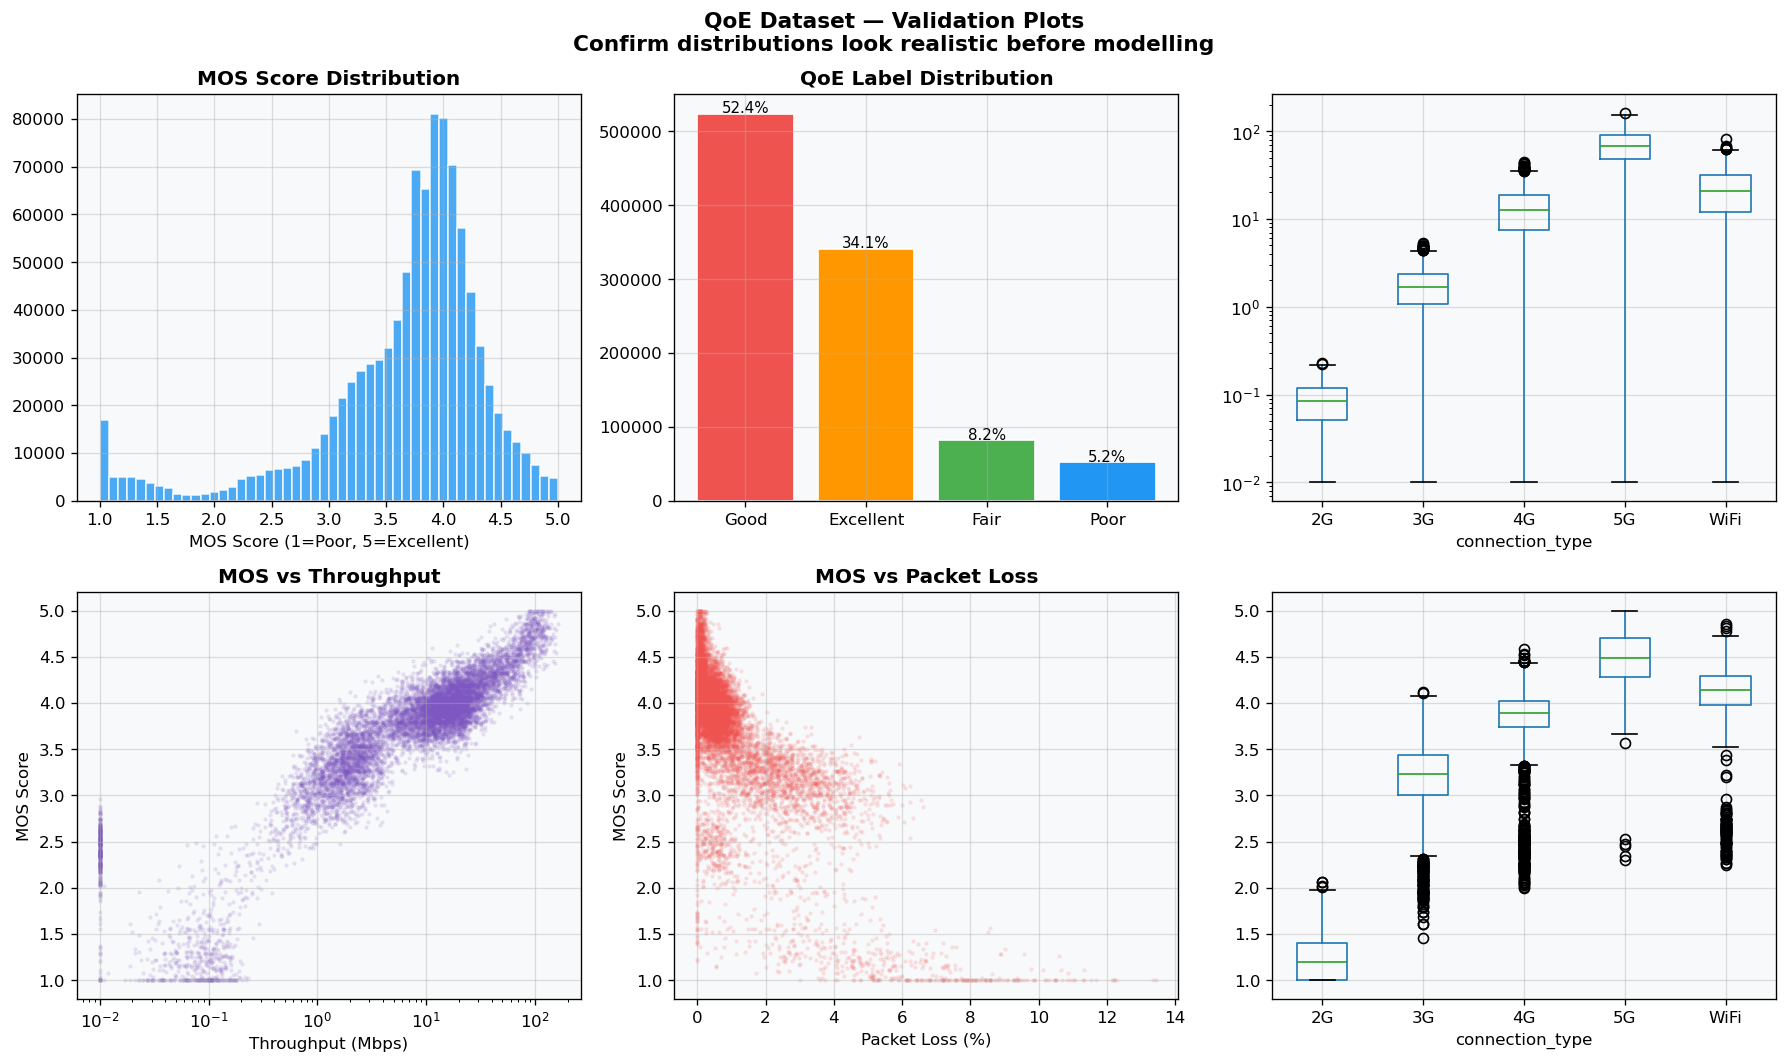

✅ Data validation complete — proceed to modelling notebooks


In [6]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Quick Validation Plots
#
# WHY VALIDATE BEFORE MODELLING:
# If the generated data has errors — like all MOS scores
# being exactly 5.0, or throughput always being 0 —
# every model trained on it will produce garbage results.
# These plots confirm the data looks realistic before
# we spend time training models on it.
# ══════════════════════════════════════════════════════════
sample = df.sample(10_000, random_state=42)  # sample for plot speed

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# MOS distribution
axes[0,0].hist(df['mos_score'], bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0,0].set_title('MOS Score Distribution', fontweight='bold')
axes[0,0].set_xlabel('MOS Score (1=Poor, 5=Excellent)')

# QoE label distribution
label_counts = df['qoe_label'].value_counts()
axes[0,1].bar(label_counts.index, label_counts.values,
              color=['#EF5350','#FF9800','#4CAF50','#2196F3'], edgecolor='white')
axes[0,1].set_title('QoE Label Distribution', fontweight='bold')
for i, (idx, val) in enumerate(label_counts.items()):
    axes[0,1].text(i, val+1000, f'{val/N*100:.1f}%', ha='center', fontsize=9)

# Throughput by connection type
sample.boxplot(column='throughput_mbps', by='connection_type', ax=axes[0,2])
axes[0,2].set_title('Throughput by Connection Type', fontweight='bold')
axes[0,2].set_yscale('log')
plt.sca(axes[0,2]); plt.title('')

# MOS vs throughput
axes[1,0].scatter(sample['throughput_mbps'], sample['mos_score'],
                   alpha=0.1, s=3, color='#7E57C2')
axes[1,0].set_xlabel('Throughput (Mbps)')
axes[1,0].set_ylabel('MOS Score')
axes[1,0].set_title('MOS vs Throughput', fontweight='bold')
axes[1,0].set_xscale('log')

# MOS vs packet loss
axes[1,1].scatter(sample['packet_loss_pct'], sample['mos_score'],
                   alpha=0.1, s=3, color='#EF5350')
axes[1,1].set_xlabel('Packet Loss (%)')
axes[1,1].set_ylabel('MOS Score')
axes[1,1].set_title('MOS vs Packet Loss', fontweight='bold')

# MOS by connection type
sample.boxplot(column='mos_score', by='connection_type', ax=axes[1,2])
axes[1,2].set_title('MOS by Connection Type', fontweight='bold')
plt.sca(axes[1,2]); plt.title('')

plt.suptitle('QoE Dataset — Validation Plots\n'
             'Confirm distributions look realistic before modelling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_00_data_validation.png', bbox_inches='tight')
plt.show()
print('✅ Data validation complete — proceed to modelling notebooks')